In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [3]:
import pandas as pd

# Giả sử df là DataFrame chứa dữ liệu Netflix của bạn
# df = pd.read_csv('netflix_titles.csv')

# Bước 1: Loại bỏ các giá trị bị thiếu (NaN) ở cột date_added để tránh lỗi khi parse
df = df.dropna(subset=['date_added'])

# Bước 2: Xóa các khoảng trắng thừa ở hai đầu chuỗi
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Bước 3: Ép kiểu dữ liệu sang datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# Bước 4 (Tùy chọn cho EDA): Trích xuất năm và tháng ra các cột riêng
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.day

df['delay_years'] = df['year_added'] - df['release_year']

In [4]:
#Do chỉ có 14 hàng mà delay_years < 0, nên drop luôn 14 hàng đó
df = df[df['delay_years'] >= 0]

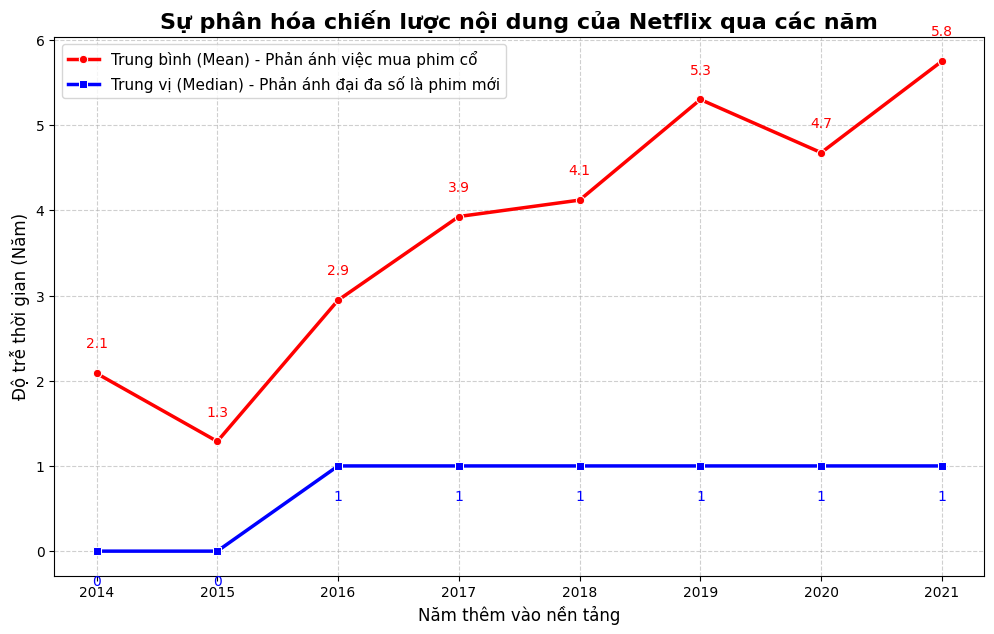

In [5]:
### Vẽ biểu đồ mean và median của delay_years theo mỗi năm

# Bước 1: Gom nhóm và tính CẢ HAI chỉ số (mean và median) cùng lúc
trend_df = df[df['year_added'] >= 2014].groupby('year_added').agg(
    mean_delay=('delay_years', 'mean'),
    median_delay=('delay_years', 'median')
).reset_index()

# Bước 2: Thiết lập kích thước biểu đồ
plt.figure(figsize=(12, 7))

# Bước 3: Vẽ đường Trung bình (Mean) - Màu đỏ
sns.lineplot(data=trend_df, x='year_added', y='mean_delay', 
             marker='o', color='red', linewidth=2.5, 
             label='Trung bình (Mean) - Phản ánh việc mua phim cổ')

# Bước 4: Vẽ đường Trung vị (Median) - Màu xanh
sns.lineplot(data=trend_df, x='year_added', y='median_delay', 
             marker='s', color='blue', linewidth=2.5, 
             label='Trung vị (Median) - Phản ánh đại đa số là phim mới')

# Bước 5: Trang trí biểu đồ để báo cáo
plt.title('Sự phân hóa chiến lược nội dung của Netflix qua các năm', fontsize=16, fontweight='bold')
plt.xlabel('Năm thêm vào nền tảng', fontsize=12)
plt.ylabel('Độ trễ thời gian (Năm)', fontsize=12)

# Hiển thị tất cả các năm trên trục X cho dễ nhìn
plt.xticks(trend_df['year_added']) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

# Tùy chọn nâng cao: Gắn trực tiếp các con số lên biểu đồ
for i, row in trend_df.iterrows():
    # Gắn số cho Mean (Lệch lên trên một chút)
    plt.text(row['year_added'], row['mean_delay'] + 0.3, f"{row['mean_delay']:.1f}", color='red', ha='center')
    # Gắn số cho Median (Lệch xuống dưới một chút)
    plt.text(row['year_added'], row['median_delay'] - 0.4, f"{row['median_delay']:.0f}", color='blue', ha='center')

# Hiển thị kết quả
plt.show()

Nhận xét biến delay_years:
- Chiến lược cốt lõi (Nhìn vào Trung vị): Luôn duy trì ở mức 0 - 1 năm. Điều này khẳng định hơn 50% nội dung Netflix tung ra luôn là phim mới, bám sát chiến lược tự sản xuất phim độc quyền (Netflix Originals).

- Dấu ấn COVID-19 (Nhìn vào Trung bình): Đột ngột vọt lên đỉnh điểm ~6 năm vào giai đoạn 2020-2021.

- Nguyên nhân: Đại dịch khiến các phim trường đóng băng. Để giữ chân khán giả ở nhà, Netflix buộc phải "chữa cháy" bằng cách mua sỉ hàng ngàn bộ phim điện ảnh kinh điển, khiến độ trễ trung bình bị kéo vọt lên.

Dữ liệu cho thấy Netflix cực kỳ linh hoạt — kiên định đầu tư nội dung mới trong dài hạn, nhưng sẵn sàng gom "hàng cổ" để sinh tồn khi có khủng hoảng.

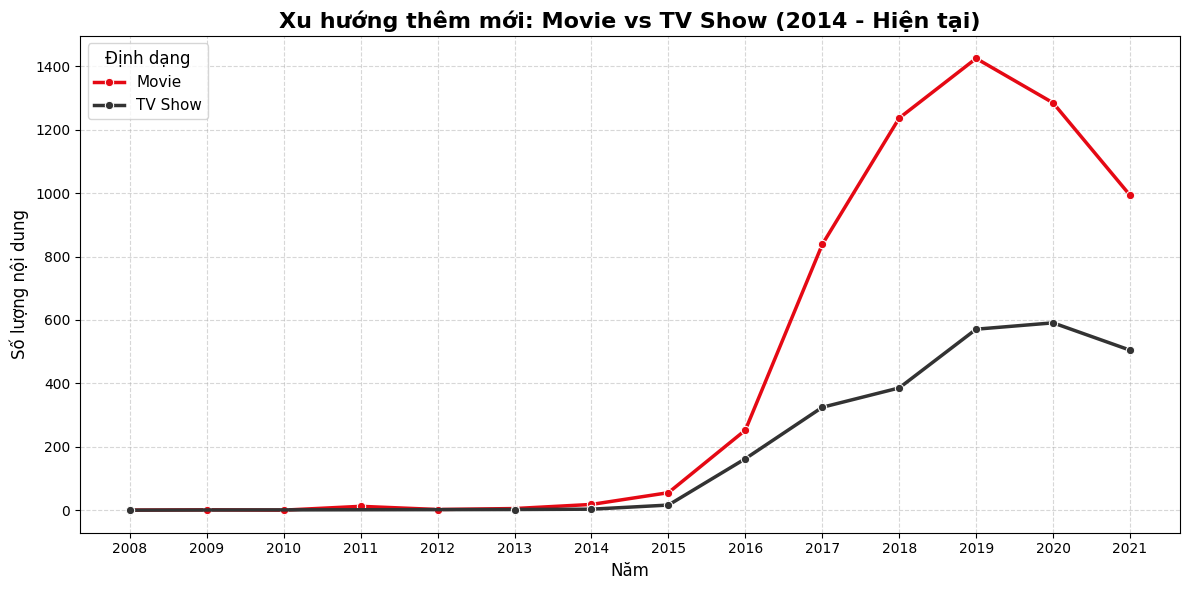

In [6]:
trend_data = df.groupby(['year_added', 'type']).size().reset_index(name='count')

# Bước 2: Thiết lập kích thước đồ thị
plt.figure(figsize=(12, 6))

# Bước 3: Dùng Seaborn vẽ biểu đồ đường
# Tham số hue='type' sẽ tự động tách 2 đường và tạo luôn Legend
sns.lineplot(data=trend_data, 
             x='year_added', 
             y='count', 
             hue='type', 
             marker='o', 
             linewidth=2.5,
             palette=['#E50914', '#333333']) # Tone màu Đỏ - Xám đậm chuẩn Netflix

# Bước 4: Trang trí cho đồ thị
plt.title('Xu hướng thêm mới: Movie vs TV Show (2014 - Hiện tại)', fontsize=16, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Số lượng nội dung', fontsize=12)

# Hiển thị tất cả các năm trên trục X
plt.xticks(trend_data['year_added'].unique())
plt.grid(True, linestyle='--', alpha=0.5)

# Tùy chỉnh Legend
plt.legend(title='Định dạng', fontsize=11, title_fontsize=12)

# Hiển thị
plt.tight_layout()
plt.show()

Nhận xét về thể loại phim

- Movie áp đảo tuyệt đối (Mồi câu user): Đường Movie luôn nằm trên và bỏ xa TV Show về khối lượng. Sản xuất hoặc mua bản quyền một bộ phim lẻ 90 phút nhanh và rẻ hơn nhiều so với show dài tập, giúp Netflix dễ dàng phình to kho thư viện để thu hút người dùng mới.

- TV Show tăng trưởng bền bỉ (Chống TLE vòng đời): Dù khối lượng ít hơn, đường TV Show lại có độ dốc tăng trưởng tịnh tiến, cực kỳ đều đặn qua các năm. Đây là vũ khí chiến lược cốt lõi để giữ chân khách hàng (retention) — khiến họ phải liên tục gia hạn gói cước để theo dõi các mùa tiếp theo.

- Đỉnh điểm 2019 - 2020: Cả hai định dạng đều bùng nổ và tạo đỉnh trong giai đoạn này. Dữ liệu này khớp hoàn hảo với sự kiện đại dịch COVID-19, thời điểm Netflix dốc toàn lực nạp nội dung (cả tự sản xuất lẫn gom hàng cũ) để phục vụ nhu cầu giải trí tại nhà tăng đột biến.

BẢNG THỐNG KÊ RATING (TOP 10):
  rating  count
0  TV-MA   3173
1  TV-14   2132
2  TV-PG    837
3      R    799
4  PG-13    490
5  TV-Y7    329
6   TV-Y    299
7     PG    287
8   TV-G    212
9     NR     78
----------------------------------------


C:\Users\HP\AppData\Local\Temp\ipykernel_4532\1951680439.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rating,


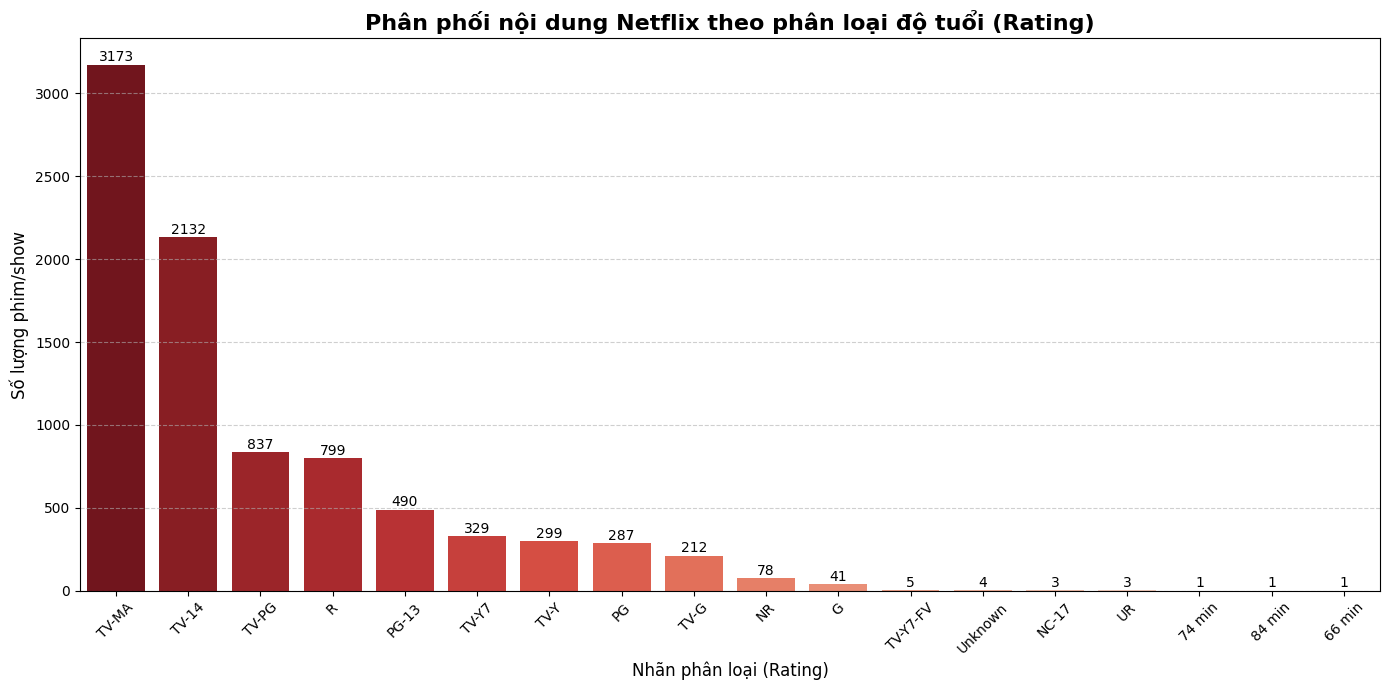

In [7]:
df_rating = df.copy()
df_rating['rating'] = df_rating['rating'].fillna('Unknown')

# Bước 2: Group và đếm số lượng từng nhãn dán rating (Tương đương việc tạo bảng tần số)
rating_counts = df_rating['rating'].value_counts().reset_index()
rating_counts.columns = ['rating', 'count']

print("BẢNG THỐNG KÊ RATING (TOP 10):")
print(rating_counts.head(10))
print("-" * 40)

# Bước 3: Vẽ biểu đồ Bar Chart để đưa vào báo cáo
plt.figure(figsize=(14, 7))

# Dùng countplot của seaborn, kết hợp với order để tự động sắp xếp cột từ cao xuống thấp
sns.countplot(data=df_rating, 
              x='rating', 
              order=df_rating['rating'].value_counts().index, 
              palette='Reds_r') # Dùng tone đỏ đậm nhạt chuẩn Netflix

# Bước 4: Trang trí biểu đồ
plt.title('Phân phối nội dung Netflix theo phân loại độ tuổi (Rating)', fontsize=16, fontweight='bold')
plt.xlabel('Nhãn phân loại (Rating)', fontsize=12)
plt.ylabel('Số lượng phim/show', fontsize=12)
plt.xticks(rotation=45) # Xoay nhãn trục X 45 độ để không bị đè chữ (chống lỗi hiển thị)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Gắn số lượng trực tiếp lên từng cột để biểu đồ có giá trị báo cáo cao nhất
for i, v in enumerate(df_rating['rating'].value_counts()):
    plt.text(i, v + 20, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Dựa vào biểu đồ, ta thấy số phim được rating là TV-MA (phim dành cho người lớn) chiếm áp đảo. Đứng thứ hai là TV-14 (dành cho 14 tuổi trở lên). Các phim khác chiếm thiểu số

Lý do có sự chênh lệch: Netflix biết rất rõ họ không thể đấu lại Disney+ ở mảng nội dung gia đình và trẻ em. Vì vậy, để sinh tồn và khác biệt hóa, Netflix đã dồn tổng lực phát triển nội dung trưởng thành, giật gân, bạo lực hoặc tâm lý phức tạp (như Squid Game, Narcos). Bài toán phân tích này chứng minh sự chuyển dịch định vị thương hiệu rất khôn ngoan.

C:\Users\HP\AppData\Local\Temp\ipykernel_4532\3315436469.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='count', y='country', palette='viridis')


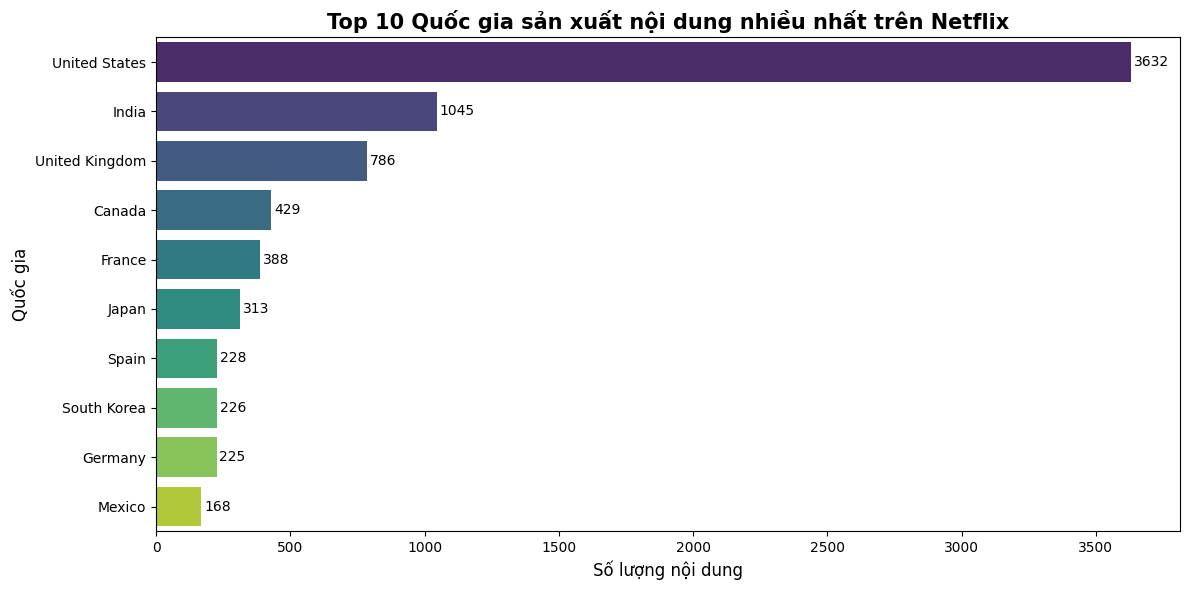

In [8]:
df_country = df.copy()

# 1. TRÁNH MẤT DỮ LIỆU: Điền NaN bằng 'Unknown'
df_country['country'] = df_country['country'].fillna('Unknown')

# 2. XỬ LÝ PHIM ĐA QUỐC GIA: 
# Chuyển chuỗi "US, UK" thành list ["US", "UK"] (nhớ xóa khoảng trắng thừa ở 2 đầu)
df_country['country'] = df_country['country'].apply(lambda x: [c.strip() for c in x.split(',')] if x != 'Unknown' else ['Unknown'])

# Dùng hàm explode để nhân bản các hàng chứa list thành nhiều hàng đơn lẻ
df_exploded = df_country.explode('country')

# 3. Lọc bỏ các hàng 'Unknown' khi vẽ biểu đồ để khỏi bị nhiễu
top_countries = df_exploded[df_exploded['country'] != 'Unknown']['country'].value_counts().head(10).reset_index()
top_countries.columns = ['country', 'count']

# 4. Vẽ biểu đồ trực quan Top 10 quốc gia
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='count', y='country', palette='viridis')

plt.title('Top 10 Quốc gia sản xuất nội dung nhiều nhất trên Netflix', fontsize=15, fontweight='bold')
plt.xlabel('Số lượng nội dung', fontsize=12)
plt.ylabel('Quốc gia', fontsize=12)

# Gắn số trực tiếp lên cột
for i, v in enumerate(top_countries['count']):
    plt.text(v + 10, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

## Đánh giá Chuyên sâu: Bức tranh Địa lý và Chiến lược "Địa phương hóa" của Netflix

Thông qua biểu đồ Top 10 quốc gia sản xuất nội dung (đã xử lý bóc tách các phim đa quốc gia), ta có thể đọc vị được chiến lược bành trướng toàn cầu cực kỳ tham vọng của Netflix:

### 1. Nước Mỹ (Top 1) - Sự thống trị của "Sân nhà" và Hệ sinh thái Hollywood
* **Hiện tượng:** Kho nội dung có nguồn gốc từ Mỹ áp đảo hoàn toàn bảng xếp hạng, cao gấp hơn 3 lần so với vị trí thứ hai.
* **Insight kinh doanh:** Với vị thế là nơi khai sinh nền tảng, việc bảo vệ "thị trường nội địa" (Home Market) là ưu tiên số một. Nước Mỹ có hệ sinh thái Hollywood khổng lồ, cho phép Netflix dễ dàng ký kết các hợp đồng bản quyền lớn ngay từ thời kỳ đầu. Tuy nhiên, sự chênh lệch này cũng phản ánh một bài toán: Thị trường Bắc Mỹ đang tiến tới điểm bão hòa, buộc Netflix phải dùng "con bò sữa" nội dung Mỹ để tạo dòng tiền đi thâu tóm các thị trường khác.

### 2. Ấn Độ (Top 2) - Tham vọng thâu tóm thị trường tỷ dân
* **Hiện tượng:** Vượt qua hàng loạt cường quốc điện ảnh phương Tây, Ấn Độ chễm chệ ở vị trí Á quân. Đặc biệt, gần 90% nội dung từ Ấn Độ trên Netflix là định dạng Movie (Phim chiếu rạp).
* **Insight kinh doanh:** Đây là nước cờ chiến lược mang tên "Volume over ARPU" (Ưu tiên số lượng người dùng hơn doanh thu trên từng người). Ấn Độ là quốc gia tỷ dân với văn hóa cuồng nhiệt điện ảnh Bollywood và giá cước internet rẻ. Netflix đã vung tiền gom hàng ngàn bộ phim Bollywood để nhanh chóng xác lập thị phần tại đây, biến Ấn Độ thành động lực tăng trưởng thuê bao mới quan trọng bậc nhất của hãng.

### 3. Vương quốc Anh (Top 3) - Cú bắt tay "Xuyên Đại Tây Dương"
* **Hiện tượng:** Vương quốc Anh là đại diện châu Âu mạnh nhất và đứng vững ở vị trí thứ 3.
* **Insight kinh doanh:** Anh sở hữu lợi thế lớn về sự tương đồng ngôn ngữ và văn hóa với Mỹ. Thay vì tự gánh toàn bộ chi phí, Netflix thường xuyên áp dụng chiến lược **Co-production (Hợp tác sản xuất)** với các đài truyền hình lớn của Anh (như BBC, Channel 4) để tạo ra các dự án chất lượng cao (Prestige TV) như *The Crown* hay *Black Mirror*, vừa tiết kiệm rủi ro tài chính vừa đảm bảo chất lượng học thuật.

### 4. Hàn Quốc & Nhật Bản - Mũi nhọn "Quyền lực mềm" xuất khẩu toàn cầu
* **Hiện tượng:** Dù nằm ở nửa dưới của Top 10, nội dung của Hàn Quốc (K-Drama) và Nhật Bản (Anime) lại thiên lệch cực mạnh về định dạng TV Show. 
* **Insight kinh doanh:** Nếu nội dung Ấn Độ chủ yếu phục vụ chính người Ấn, thì nội dung Hàn/Nhật được Netflix đầu tư để **xuất khẩu toàn cầu**. Khả năng gây nghiện (binge-watching) và mức độ phủ sóng mạng xã hội (viral) của K-Drama (*Squid Game*, *The Glory*) hay Anime là vũ khí sắc bén nhất để Netflix lôi kéo và giữ chân tệp khán giả trẻ (Gen Z, Millennials) ở mọi ngóc ngách trên thế giới.

### 5. Khối Tây Ban Nha & Mỹ Latinh (Tây Ban Nha, Mexico) - Định hình hệ sinh thái ngôn ngữ
* **Hiện tượng:** Tây Ban Nha và Mexico luôn bám đuổi sát sao trong bảng xếp hạng.
* **Insight kinh doanh:** Tiếng Tây Ban Nha là ngôn ngữ phổ biến thứ hai trên thế giới (theo số lượng người bản ngữ). Bằng việc bơm vốn cho các siêu phẩm như *Money Heist (La Casa de Papel)* hay *Elite*, Netflix không chỉ đánh chiếm thị trường Nam Âu mà còn tạo ra một "mỏ neo" vững chắc để thống trị toàn bộ khu vực Mỹ Latinh.